<p align="center">
  <b><font size="6">COVID19 Data Analysis</font></b>
</p>


## 1. Import libraries

We use common Python data analysis libraries:

- `pathlib` for Windows-friendly file paths
- `pandas` and `numpy` for data work
- `matplotlib` and `seaborn` for local plots

In [1]:
# pathlib helps us build file paths that work on Windows, macOS, and Linux.
from pathlib import Path

# pandas and numpy are used for loading and analyzing tabular data.
import numpy as np
import pandas as pd

# matplotlib and seaborn are used for charts that work locally in Jupyter.
import matplotlib.pyplot as plt
import seaborn as sns

# Make charts look clean and readable.
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

## 2. Set the output folder



In [2]:
# This is the folder where the notebook will save plots and CSV summaries.
OUTPUT_DIR = Path("outputs")

# Create the outputs folder if it does not already exist.
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Output folder: {OUTPUT_DIR}")

Output folder: outputs


## 3. Load the local CSV files



In [3]:
# Load each CSV file directly from the Data folder.
clean_complete = pd.read_csv("covid_19_clean_complete.csv", parse_dates=["Date"])
country_latest = pd.read_csv("country_wise_latest.csv")
day_wise = pd.read_csv("day_wise.csv", parse_dates=["Date"])
full_grouped = pd.read_csv("full_grouped.csv", parse_dates=["Date"])
worldometer = pd.read_csv("worldometer_data.csv")

print("Data loaded successfully!")
print(f"clean_complete shape: {clean_complete.shape}")
print(f"country_latest shape: {country_latest.shape}")
print(f"day_wise shape: {day_wise.shape}")
print(f"full_grouped shape: {full_grouped.shape}")
print(f"worldometer shape: {worldometer.shape}")

Data loaded successfully!
clean_complete shape: (49068, 10)
country_latest shape: (187, 15)
day_wise shape: (188, 12)
full_grouped shape: (35156, 10)
worldometer shape: (209, 16)


## 4. Quick look at the data

`head()` shows the first few rows, and `info()` shows columns, data types, and missing values.

In [4]:
# Display the first five rows of the main country-level table.
country_latest.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [5]:
# Display column information for the daily global table.
day_wise.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    188 non-null    datetime64[ns]
 1   Confirmed               188 non-null    int64         
 2   Deaths                  188 non-null    int64         
 3   Recovered               188 non-null    int64         
 4   Active                  188 non-null    int64         
 5   New cases               188 non-null    int64         
 6   New deaths              188 non-null    int64         
 7   New recovered           188 non-null    int64         
 8   Deaths / 100 Cases      188 non-null    float64       
 9   Recovered / 100 Cases   188 non-null    float64       
 10  Deaths / 100 Recovered  188 non-null    float64       
 11  No. of countries        188 non-null    int64         
dtypes: datetime64[ns](1), float64(3), int64(8)
memory 

## 5. Basic summary statistics


In [6]:
# Sort countries by total confirmed cases.
top_10_confirmed = country_latest.sort_values("Confirmed", ascending=False).head(10)

# Select beginner-friendly columns for a compact summary.
summary_columns = ["Country/Region", "Confirmed", "Deaths", "Recovered", "Active"]
top_10_summary = top_10_confirmed[summary_columns].copy()

# Save the summary table to outputs so generated files stay outside the data folder.
summary_path = OUTPUT_DIR / "beginner_top_10_countries_summary.csv"
top_10_summary.to_csv(summary_path, index=False)

print(f"Saved summary CSV to: {summary_path}")
top_10_summary

Saved summary CSV to: outputs/beginner_top_10_countries_summary.csv


,Country/Region,Confirmed,Deaths,Recovered,Active
173,US,4290259,148011,1325804,2816444
23,Brazil,2442375,87618,1846641,508116
79,India,1480073,33408,951166,495499
138,Russia,816680,13334,602249,201097
154,South Africa,452529,7067,274925,170537
111,Mexico,395489,44022,303810,47657
132,Peru,389717,18418,272547,98752
35,Chile,347923,9187,319954,18782
177,United Kingdom,301708,45844,1437,254427
81,Iran,293606,15912,255144,22550


## 6. Plot: Top 10 countries by confirmed cases

This bar chart compares the countries with the highest confirmed case counts.

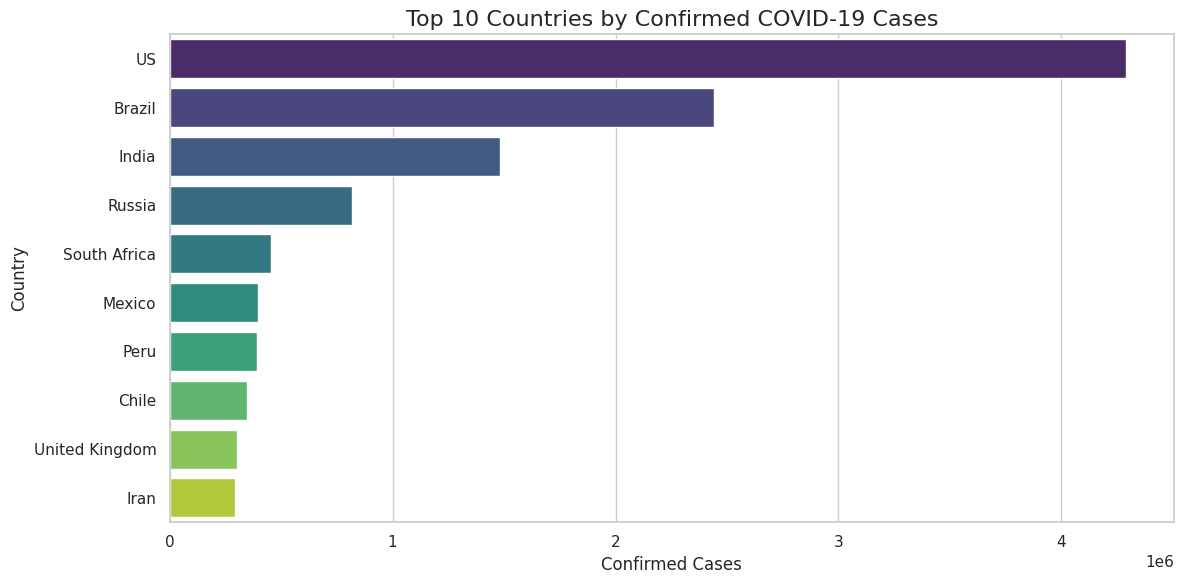

Saved plot to: outputs/top_10_confirmed_cases.png


In [7]:
# Create a bar chart for the top 10 countries by confirmed cases.
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_10_confirmed, x="Confirmed", y="Country/Region", hue="Country/Region", palette="viridis", legend=False, ax=ax)
ax.set_title("Top 10 Countries by Confirmed COVID-19 Cases")
ax.set_xlabel("Confirmed Cases")
ax.set_ylabel("Country")

# Save the plot locally to outputs.
plot_path = OUTPUT_DIR / "top_10_confirmed_cases.png"
fig.tight_layout()
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved plot to: {plot_path}")

## 7. Plot: Global COVID-19 trend over time

The `day_wise.csv` file contains global totals by date. Line charts are useful for seeing how numbers changed over time.

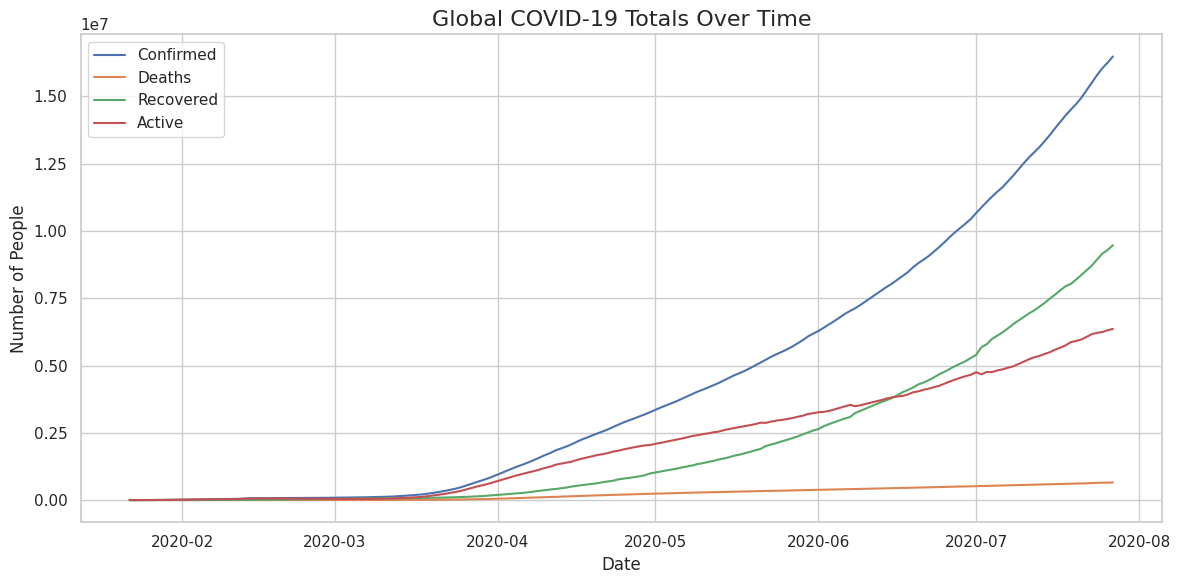

Saved plot to: outputs/global_covid_totals_over_time.png


In [8]:
# Plot total confirmed cases, deaths, recoveries, and active cases over time.
fig, ax = plt.subplots(figsize=(12, 6))
for column in ["Confirmed", "Deaths", "Recovered", "Active"]:
    ax.plot(day_wise["Date"], day_wise[column], label=column)

ax.set_title("Global COVID-19 Totals Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Number of People")
ax.legend()

# Save the plot locally to outputs.
plot_path = OUTPUT_DIR / "global_covid_totals_over_time.png"
fig.tight_layout()
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved plot to: {plot_path}")

## 8. Plot: Daily new cases

Daily new cases show the number of newly reported confirmed cases each day.

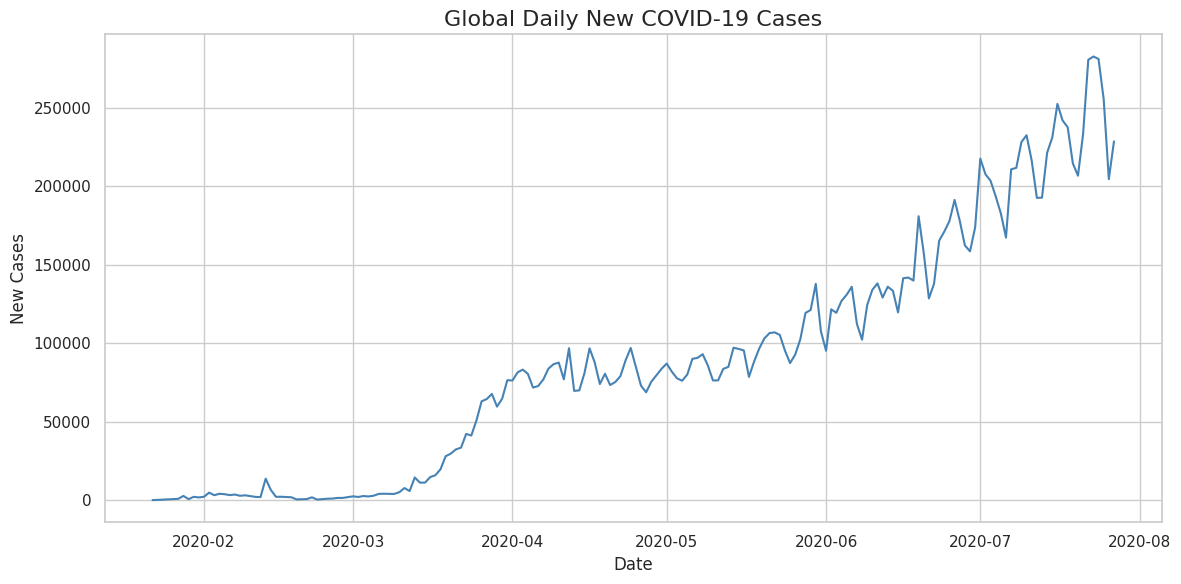

Saved plot to: outputs/global_daily_new_cases.png


In [9]:
# Create a line chart for daily new confirmed cases.
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=day_wise, x="Date", y="New cases", color="steelblue", ax=ax)
ax.set_title("Global Daily New COVID-19 Cases")
ax.set_xlabel("Date")
ax.set_ylabel("New Cases")

# Save the plot locally to outputs.
plot_path = OUTPUT_DIR / "global_daily_new_cases.png"
fig.tight_layout()
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved plot to: {plot_path}")

## 9. Plot: Confirmed cases by WHO region

Grouping data helps us compare larger categories. Here we group countries by WHO region.

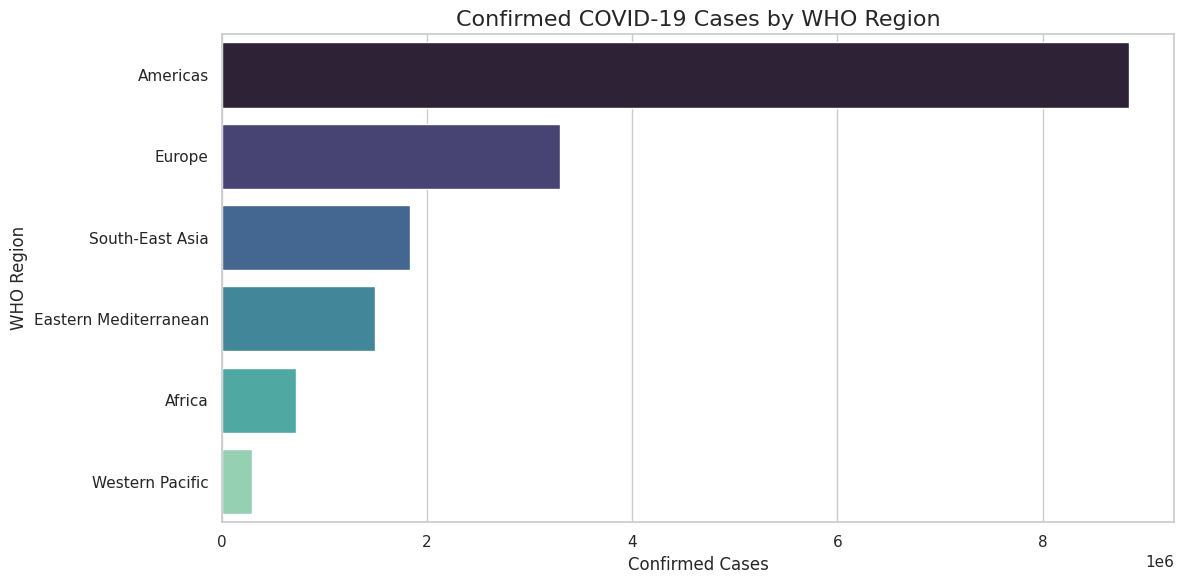

Saved region summary to: outputs/beginner_who_region_summary.csv
Saved plot to: outputs/confirmed_cases_by_who_region.png


,WHO Region,Confirmed,Deaths,Recovered,Active
1,Americas,8839286,342732,4468616,4027938
3,Europe,3299523,211144,1993723,1094656
4,South-East Asia,1835297,41349,1156933,637015
2,Eastern Mediterranean,1490744,38339,1201400,251005
0,Africa,723207,12223,440645,270339
5,Western Pacific,292428,8249,206770,77409


In [10]:
# Add confirmed cases within each WHO region.
region_summary = (
    country_latest.groupby("WHO Region", as_index=False)[["Confirmed", "Deaths", "Recovered", "Active"]]
    .sum()
    .sort_values("Confirmed", ascending=False)
)

# Save the region summary table.
region_summary_path = OUTPUT_DIR / "beginner_who_region_summary.csv"
region_summary.to_csv(region_summary_path, index=False)

# Create a bar chart by WHO region.
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=region_summary, x="Confirmed", y="WHO Region", hue="WHO Region", palette="mako", legend=False, ax=ax)
ax.set_title("Confirmed COVID-19 Cases by WHO Region")
ax.set_xlabel("Confirmed Cases")
ax.set_ylabel("WHO Region")

# Save the plot locally to outputs.
plot_path = OUTPUT_DIR / "confirmed_cases_by_who_region.png"
fig.tight_layout()
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved region summary to: {region_summary_path}")
print(f"Saved plot to: {plot_path}")
region_summary

## 10. Plot: Cases and deaths by continent

The `worldometer_data.csv` file includes continent information, which lets us compare broader geographic groups.

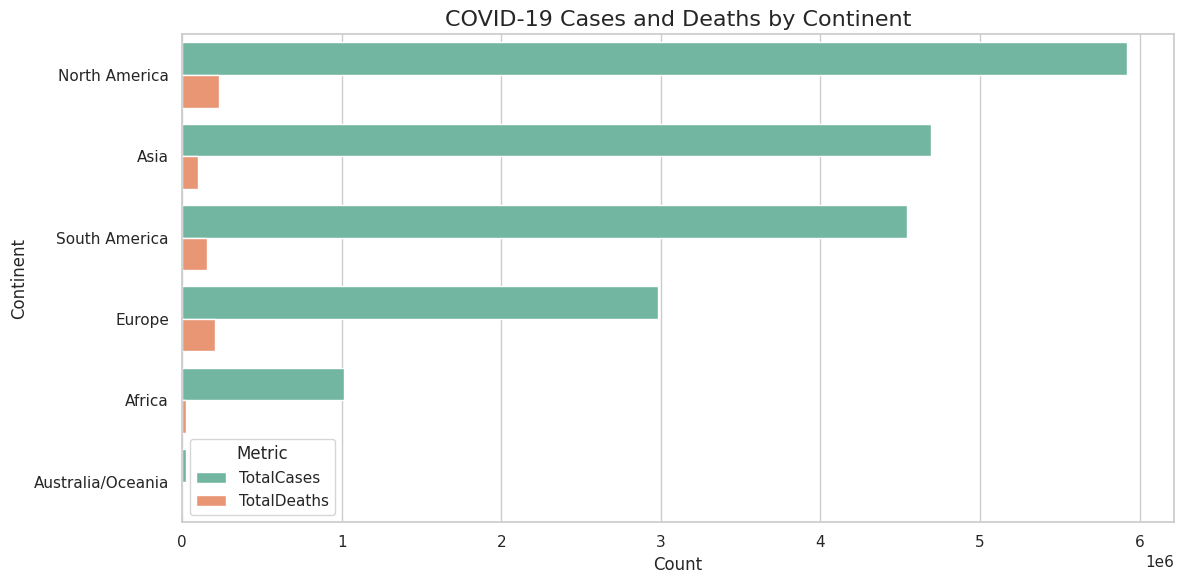

Saved continent summary to: outputs/beginner_continent_summary.csv
Saved plot to: outputs/cases_and_deaths_by_continent.png


,Continent,TotalCases,TotalDeaths,TotalRecovered,ActiveCases
4,North America,5919209,229855.0,3151678.0,2537676.0
1,Asia,4689794,100627.0,3508170.0,1080997.0
5,South America,4543273,154885.0,3116150.0,1272238.0
3,Europe,2982576,205232.0,1587302.0,475261.0
0,Africa,1011867,22114.0,693620.0,296133.0
2,Australia/Oceania,21735,281.0,12620.0,8834.0


In [11]:
# Clean continent values before grouping.
worldometer_clean = worldometer.dropna(subset=["Continent"]).copy()

# Group worldometer data by continent.
continent_summary = (
    worldometer_clean.groupby("Continent", as_index=False)[["TotalCases", "TotalDeaths", "TotalRecovered", "ActiveCases"]]
    .sum()
    .sort_values("TotalCases", ascending=False)
)

# Save the continent summary table.
continent_summary_path = OUTPUT_DIR / "beginner_continent_summary.csv"
continent_summary.to_csv(continent_summary_path, index=False)

# Create a comparison chart for cases and deaths by continent.
plot_data = continent_summary.melt(
    id_vars="Continent",
    value_vars=["TotalCases", "TotalDeaths"],
    var_name="Metric",
    value_name="Count",
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=plot_data, x="Count", y="Continent", hue="Metric", palette="Set2", ax=ax)
ax.set_title("COVID-19 Cases and Deaths by Continent")
ax.set_xlabel("Count")
ax.set_ylabel("Continent")

# Save the plot locally to outputs.
plot_path = OUTPUT_DIR / "cases_and_deaths_by_continent.png"
fig.tight_layout()
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved continent summary to: {continent_summary_path}")
print(f"Saved plot to: {plot_path}")
continent_summary

## 11. Country trend example

The `full_grouped.csv` file lets us filter one country and see its trend over time. You can change `country_name` to another country in the dataset.

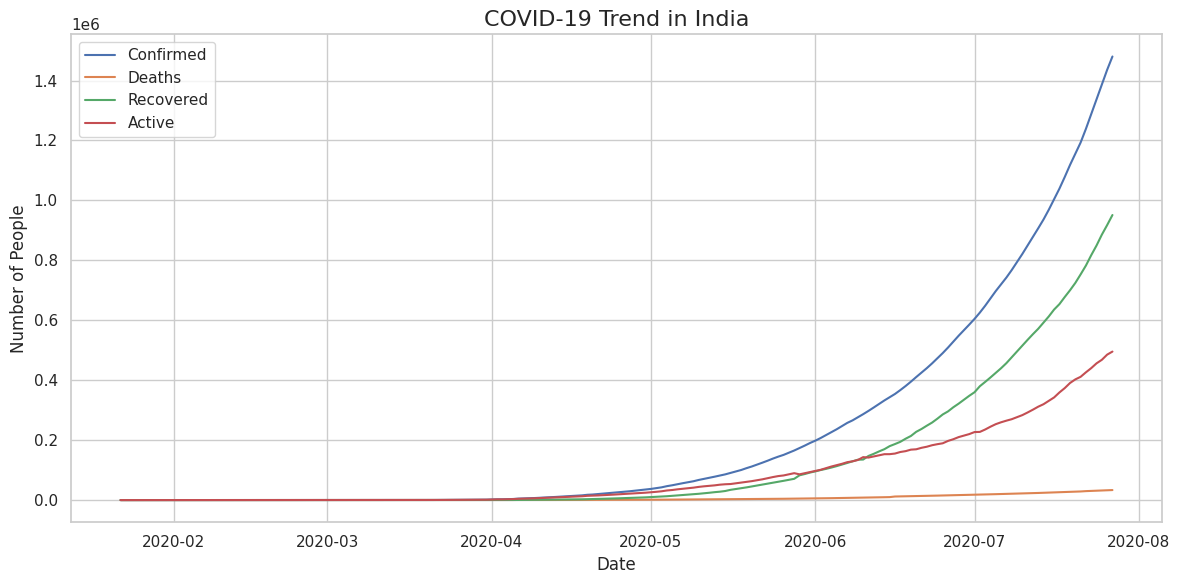

Saved plot to: outputs/india_covid_trend.png


In [12]:
# Choose one country to inspect. Change this value to try another country.
country_name = "India"

# Filter rows for the selected country and sort by date.
country_trend = full_grouped.loc[full_grouped["Country/Region"] == country_name].sort_values("Date")

if country_trend.empty:
    raise ValueError(f"No rows found for country: {country_name}")

# Plot confirmed, deaths, recovered, and active cases for the selected country.
fig, ax = plt.subplots(figsize=(12, 6))
for column in ["Confirmed", "Deaths", "Recovered", "Active"]:
    ax.plot(country_trend["Date"], country_trend[column], label=column)

ax.set_title(f"COVID-19 Trend in {country_name}")
ax.set_xlabel("Date")
ax.set_ylabel("Number of People")
ax.legend()

# Save the plot locally to outputs.
safe_country_name = country_name.lower().replace(" ", "_")
plot_path = OUTPUT_DIR / f"{safe_country_name}_covid_trend.png"
fig.tight_layout()
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved plot to: {plot_path}")

## 12. Final notes
All files created by the notebook are saved in `outputs/`.